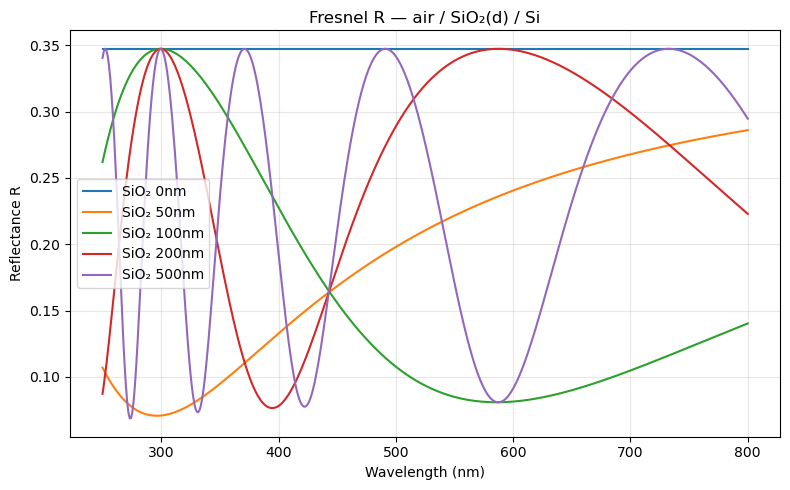

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def n_SiO2(lam_nm):
    """Cauchy 근사: SiO2 굴절률 (단순화)"""
    lam_um = lam_nm / 1000
    return 1.4580 + 0.00354 / lam_um**2

def fresnel_R_film(n0, n1, n2, d_nm, lam_nm):
    """
    단층막 (air/SiO2/Si) Fresnel 반사율
    n0: 입사 매질 (air=1.0)
    n1: 박막 (SiO2)
    n2: 기판 (Si, 복소수)
    d_nm: 막 두께 (nm)
    lam_nm: 파장 (nm)
    """
    # 계면 반사 계수
    r01 = (n0 - n1) / (n0 + n1)
    r12 = (n1 - n2) / (n1 + n2)
    
    # 위상 두께
    delta = 2 * np.pi * n1 * d_nm / lam_nm
    
    # 전체 반사 계수 (다중 반사 합산)
    r_total = (r01 + r12 * np.exp(2j * delta)) / \
              (1 + r01 * r12 * np.exp(2j * delta))
    
    return np.abs(r_total)**2

# 파장 범위
wavelengths = np.linspace(250, 800, 500)

# Si 복소 굴절률 (단순화된 고정값)
n_Si = 3.87 + 0.02j

# 다양한 두께에서의 반사율 계산
fig, ax = plt.subplots(figsize=(8, 5))

for d_nm in [0, 50, 100, 200, 500]:
    R = [fresnel_R_film(1.0, n_SiO2(lam), n_Si, d_nm, lam)
         for lam in wavelengths]
    ax.plot(wavelengths, R, label=f"SiO₂ {d_nm}nm")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance R")
ax.set_title("Fresnel R — air / SiO₂(d) / Si")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fresnel_R.png", dpi=150)
plt.show()